# Détection de Posture - 20/04/2026

Dans ce notebook, nous verrons comment l'IA peut être utilisée pour détecter la posture de personnages. Comme dans le cas de la détection d'objets, nous verrons deux approches : spécifiques et par VLM/LLM.

Comme toujours, toutes les cellules peuvent être executées dans l'ordre, mais essayez de prédire la sortie de chaque cellule avant de l'exécuter.
N'hésitez pas à jouer avec le code, le bidouiller pour tester des alternatives — c'est l'un des grands avantages d'utiliser un notebook.

In [ ]:
# The client gets the API key from the environment variable `GEMINI_API_KEY`.
from google import genai

client = genai.Client(api_key=YOUR_API_HERE)

from google.genai import types
from PIL import Image
import math
from io import BytesIO
import base64
import json
import numpy as np
import os
import cv2

from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision

import matplotlib.pyplot as plt


## Option 1 - Mediapipe / Landmarker


De la même manière que la semaine dernière, nous avons vu qu'il était possible d'utiliser un modèle dédié pour la détection d'objet, nous allons voir d'abord un réseau spécifique pour les poses : `mediapipe`

In [5]:

def return_coords(normalized_x,normalized_y,image_width,image_height):
  x_px = min(math.floor(normalized_x * image_width), image_width - 1)
  y_px = min(math.floor(normalized_y * image_height), image_height - 1)

  return (x_px,y_px)

In [6]:

# ETAPE 1: Importer les bonnes librairies
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

I0000 00:00:1776672328.666927 20761709 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1776672328.759780 20761710 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776672328.835538 20761710 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776672329.015792 20761716 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


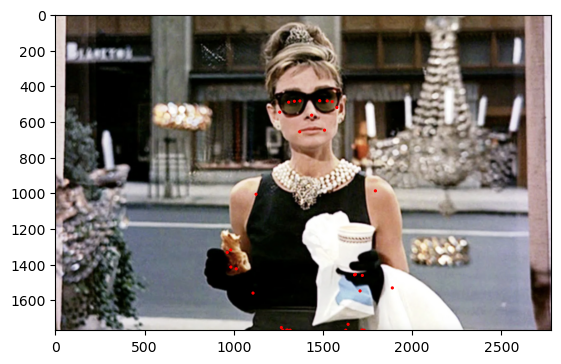

In [7]:

IMAGE_PATH = "./data/cours_14-04/cinema2.png"

# ETAPE 2: Créer un objet PoseLandmarker. Ici, le modèle est initialisé pour détecter la présence de personnes.
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)

# ETAPE 3: Charger l'image
image = mp.Image.create_from_file(IMAGE_PATH)

# ETAPE 4: Detecter les postures des personnes dans l'image
detection_result = detector.detect(image)

# ETAPE 5: Visualisons les résultats

im = np.array(Image.open(IMAGE_PATH))
fig, ax = plt.subplots(1)
ax.imshow(im)
for landmark in detection_result.pose_landmarks[0]:
  ax.add_patch(plt.Circle((return_coords(landmark.x,landmark.y,image.width,image.height)), 5, color='r'))


❓ Sous quelle forme le réseau vous renvoie-t'il la posture des personnes ?

Pour cela allez voir dans l'objet `detection_result`

In [10]:
detection_result

PoseLandmarkerResult(pose_landmarks=[[NormalizedLandmark(x=0.5172619819641113, y=0.3183739185333252, z=-0.6530050039291382, visibility=0.9998779296875, presence=0.9995622038841248, name=None), NormalizedLandmark(x=0.5332968831062317, y=0.2723386287689209, z=-0.6159217953681946, visibility=0.9994749426841736, presence=0.9988723397254944, name=None), NormalizedLandmark(x=0.5484388470649719, y=0.2731552720069885, z=-0.6163855791091919, visibility=0.9995831847190857, presence=0.9987108707427979, name=None), NormalizedLandmark(x=0.5585628747940063, y=0.2753264904022217, z=-0.6163743734359741, visibility=0.9992344379425049, presence=0.9977877140045166, name=None), NormalizedLandmark(x=0.4931735098361969, y=0.2730591893196106, z=-0.6104272603988647, visibility=0.9998210072517395, presence=0.9992627501487732, name=None), NormalizedLandmark(x=0.4822571873664856, y=0.27421247959136963, z=-0.6108673214912415, visibility=0.9999220371246338, presence=0.999517560005188, name=None), NormalizedLandmar

❗ Nous pouvons extraire le résultat de la première étape (la détection de personnes) pour savoir si le modèle a bien réussi à tout capter.

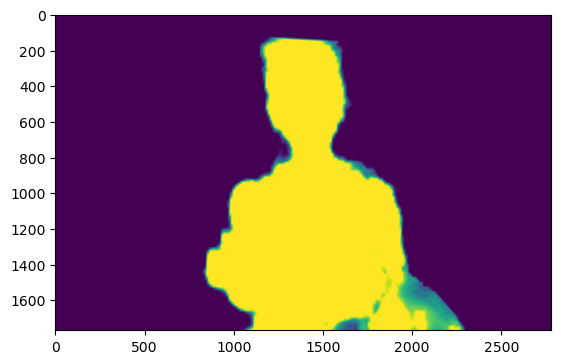

In [11]:
segmentation_mask = detection_result.segmentation_masks[0].numpy_view()
segmentation_mask = np.squeeze(segmentation_mask)

plt.imshow(segmentation_mask)

❗ Essayons désormais de voir si le réseau est capable de gérer d'autres types d'images (notamment sur lesquelles il n'a pas été entraîné):

In [12]:
def get_posture_path(image_path):


    # ETAPE 2: Créer un objet PoseLandmarker. Ici, le modèle est initialisé pour détecter la présence de personnes.
    base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        output_segmentation_masks=True)
    detector = vision.PoseLandmarker.create_from_options(options)

    # ETAPE 3: Charger l'image
    image = mp.Image.create_from_file(image_path)

    # ETAPE 4: Detecter les postures des personnes dans l'image
    detection_result = detector.detect(image)

    # ETAPE 5: Visualisons les résultats

    im = np.array(Image.open(image_path))
    fig, ax = plt.subplots(1)
    ax.imshow(im)
    
    for landmark in detection_result.pose_landmarks:
        for position in landmark:
            ax.add_patch(plt.Circle((return_coords(position.x,position.y,image.width,image.height)), 5, color='r'))

    plt.show()


I0000 00:00:1776672372.884174 20762364 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1 Pro
W0000 00:00:1776672372.975909 20762368 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776672372.997338 20762368 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


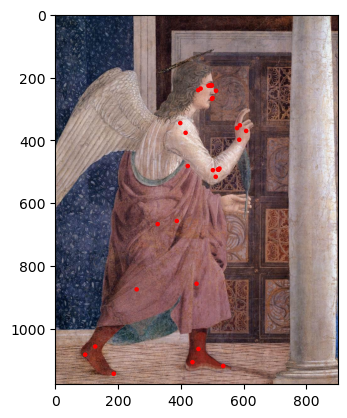

In [13]:
get_posture_path("./data/cours_23-03/piero/31325.jpg")

I0000 00:00:1776672378.235286 20762420 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1 Pro
W0000 00:00:1776672378.328924 20762423 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776672378.349389 20762425 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


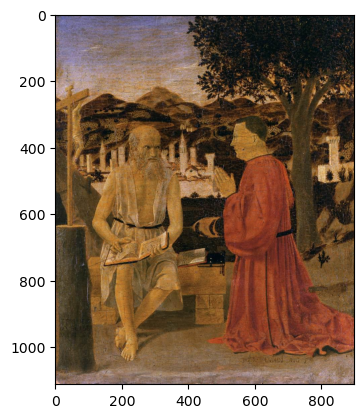

In [14]:
get_posture_path("./data/cours_23-03/piero/31391.jpg")

❓ Là encore, réfléchissons aux avantages et inconvénients de ce modèle.

*Votre réponse ici*

## Option 2 - Gemini

Reprenons la même idée que la dernière fois : passer par un LLM/VLM pour réaliser cette tâche de détection de posture de manière plus versatile.

Il suffit (en principe) de changer le *prompt* pour obtenir les résultats que l'on cherche.

In [98]:
prompt = "For every person in this fresco, detect their pose and return the points that draw their posture"  # @param {type:"string"}

image_path = './data/cours_23-03/piero/31391.jpg'
#image_path = './data/cours_23-03/piero/31333.jpg'

im = Image.open(BytesIO(open(image_path, "rb").read()))

# Run model to find bounding boxes
response = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents=[prompt, im],
    config = types.GenerateContentConfig(
        temperature=0.5,
        thinking_config=types.ThinkingConfig(
          thinking_budget=0
        )
    )
)


def parse_json(json_output: str):
    # Parsing out the markdown fencing
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line == "```json":
            json_output = "\n".join(lines[i+1:])  # Remove everything before "```json"
            json_output = json_output.split("```")[0]  # Remove everything after the closing "```"
            break  # Exit the loop once "```json" is found
    return json_output


keypoints = eval(parse_json(response.text).replace('\n ','').replace('`','').replace('json','').replace('\n','').replace(']]',']'))

Ce qui une fois structuré donne ceci :

In [93]:
keypoints

[{'point': [81, 196], 'label': "God the Father's head"},
 {'point': [136, 115], 'label': "God the Father's right shoulder"},
 {'point': [116, 268], 'label': "God the Father's left shoulder"},
 {'point': [211, 182], 'label': "God the Father's right elbow"},
 {'point': [235, 239], 'label': "God the Father's right hand"},
 {'point': [232, 292], 'label': "God the Father's left hand"},
 {'point': [595, 318], 'label': "Angel Gabriel's head"},
 {'point': [632, 240], 'label': "Angel Gabriel's right shoulder"},
 {'point': [632, 287], 'label': "Angel Gabriel's left shoulder"},
 {'point': [669, 315], 'label': "Angel Gabriel's left elbow"},
 {'point': [645, 386], 'label': "Angel Gabriel's left hand"},
 {'point': [725, 360], 'label': "Angel Gabriel's right hand"},
 {'point': [883, 107], 'label': "Angel Gabriel's right knee"},
 {'point': [887, 297], 'label': "Angel Gabriel's left knee"},
 {'point': [915, 96], 'label': "Angel Gabriel's right foot"},
 {'point': [917, 301], 'label': "Angel Gabriel's le

Détectons les cas où plusieurs personnes co-existent

In [94]:
split_indices = []
for idx in range(len(keypoints)):
    if (keypoints[idx]['label']=='nose')&(idx!=0):
        split_indices.append(idx)

persons = []
lower_bound = 0
for split_idx in split_indices:
    persons.append(keypoints[lower_bound:split_idx])
    lower_bound = split_idx
persons.append(keypoints[lower_bound:])


Que nous pouvons représenter sur l'image originale ainsi :

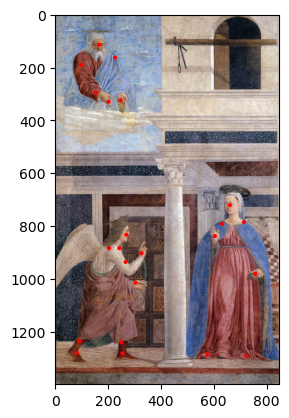

In [95]:
im = cv2.imread(image_path)
im = cv2.cvtColor(im,cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(1)
ax.imshow(im)


for person in persons:
    for keypoint in person:            
        if 'point' in keypoint.keys():
            abs_y1 = int(keypoint["point"][0]/1000 * im.shape[0])
            abs_x1 = int(keypoint["point"][1]/1000 * im.shape[1])
            ax.add_patch(plt.Circle((abs_x1,abs_y1), 5, color='r'))

            


❓ Là encore, quels avantages et inconvénients offre cette approche ?

*Votre réponse ici*

Essayons maintenant de représenter cela en squelettes :

In [96]:



fixed_pairs = [('nose','left_eye'),
               ('nose','right_eye'),
               ('right_eye','right_ear'),
               ('left_ear','left_eye'),
               ('left_shoulder','left_elbow'),
               ('left_elbow','left_wrist'),
               ('right_shoulder','right_elbow'),
               ('right_elbow','right_wrist'),
               ('left_hip','left_knee'),
               ('left_knee','left_ankle'),
               ('right_hip','right_knee'),
               ('right_knee','right_ankle')
               ]

    

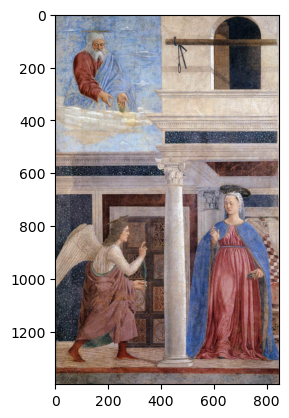

In [97]:
im = cv2.imread(image_path)
im = cv2.cvtColor(im,cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(1)
ax.imshow(im)


for person in persons:
    posture_dict = {}
    for item in person:
        posture_dict[item['label']] = item['point']

        for pair in fixed_pairs:
            try:
                abs_x1 = int(posture_dict[pair[0]][1]/1000 * im.shape[1])
                abs_x2 = int(posture_dict[pair[1]][1]/1000 * im.shape[1])
                abs_y1 = int(posture_dict[pair[0]][0]/1000 * im.shape[0])
                abs_y2 = int(posture_dict[pair[1]][0]/1000 * im.shape[0])
                
                ax.plot((abs_x1,abs_x2),(abs_y1,abs_y2), 5, color='r')
            except KeyError:
                pass


Ou bien, faisant abstraction du tableau originel :

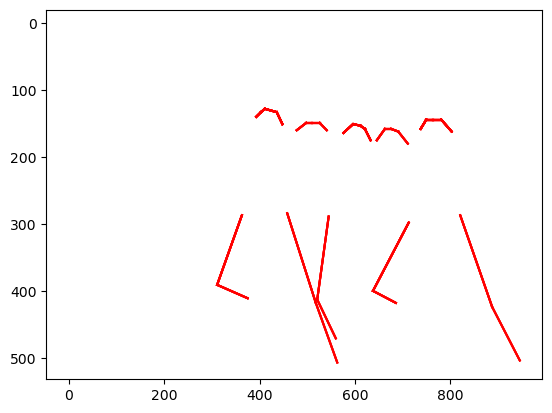

In [90]:
fig, ax = plt.subplots(1)
ax.invert_yaxis()

for person in persons:
    posture_dict = {}
    for item in person:
        posture_dict[item['label']] = item['point']

        for pair in fixed_pairs:
            try:
                abs_x1 = posture_dict[pair[0]][1]
                abs_x2 = posture_dict[pair[1]][1]
                abs_y1 = posture_dict[pair[0]][0]
                abs_y2 = posture_dict[pair[1]][0]
                
                ax.plot((abs_x1,abs_x2),(abs_y1,abs_y2), 5, color='r')
            except KeyError:
                pass